# I. Abstract

This project constructs a deep learning-based text sentiment classification pipeline. We integrated word-level and character-level TF-IDF features, feeding them into a deep neural network comprising a Gaussian noise layer, three fully connected layers, and an output layer. The model was trained using 7-fold hierarchical cross-validation, incorporating regularisation techniques such as early stopping, learning rate adjustment, category weighting, and label smoothing. Classification results were ultimately obtained through ensemble prediction probabilities derived from cross-validation, ensuring the pipeline balances model robustness with generalisation capability.

# II. Data Analysis

Analysis of the training dataset (train.csv) reveals that it comprises 386,809 samples categorised into six sentiment label classes.

| Label | Count  | Percentage |
|:------|:-------|:-----------|
| 0     | 112,464 | 29.07%     |
| 1     | 130,914 | 33.84%     |
| 2     | 32,067  | 8.29%      |
| 3     | 53,192  | 13.75%     |
| 4     | 44,278  | 11.45%     |
| 5     | 13,894  | 3.59%      |

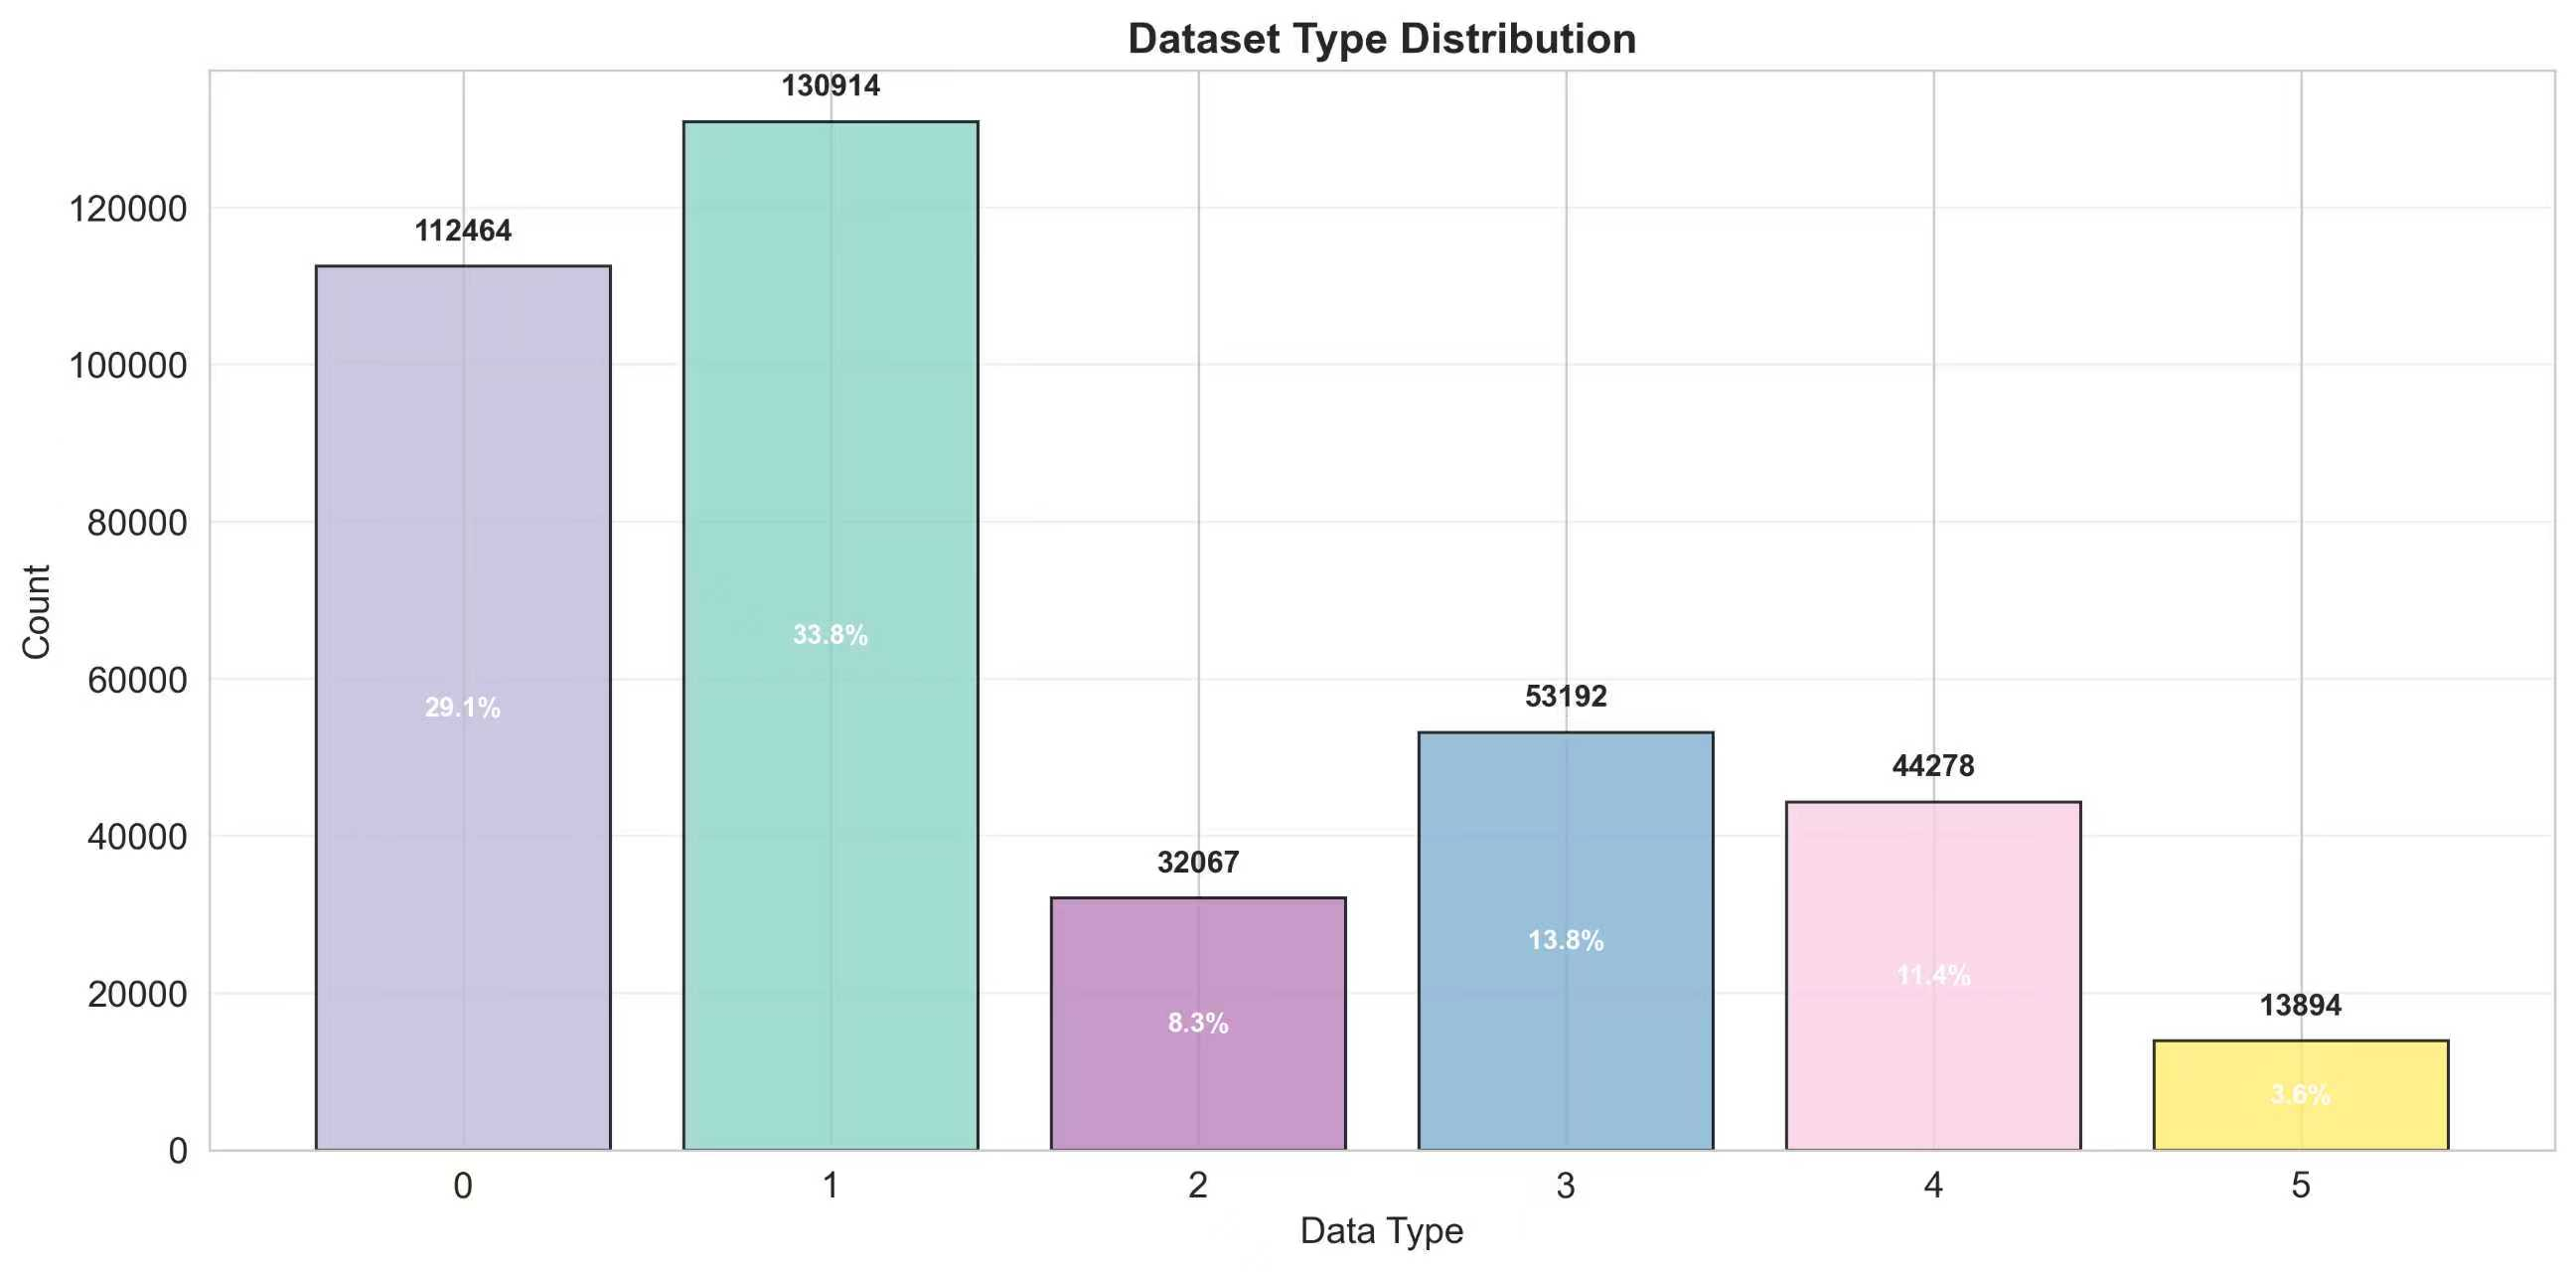
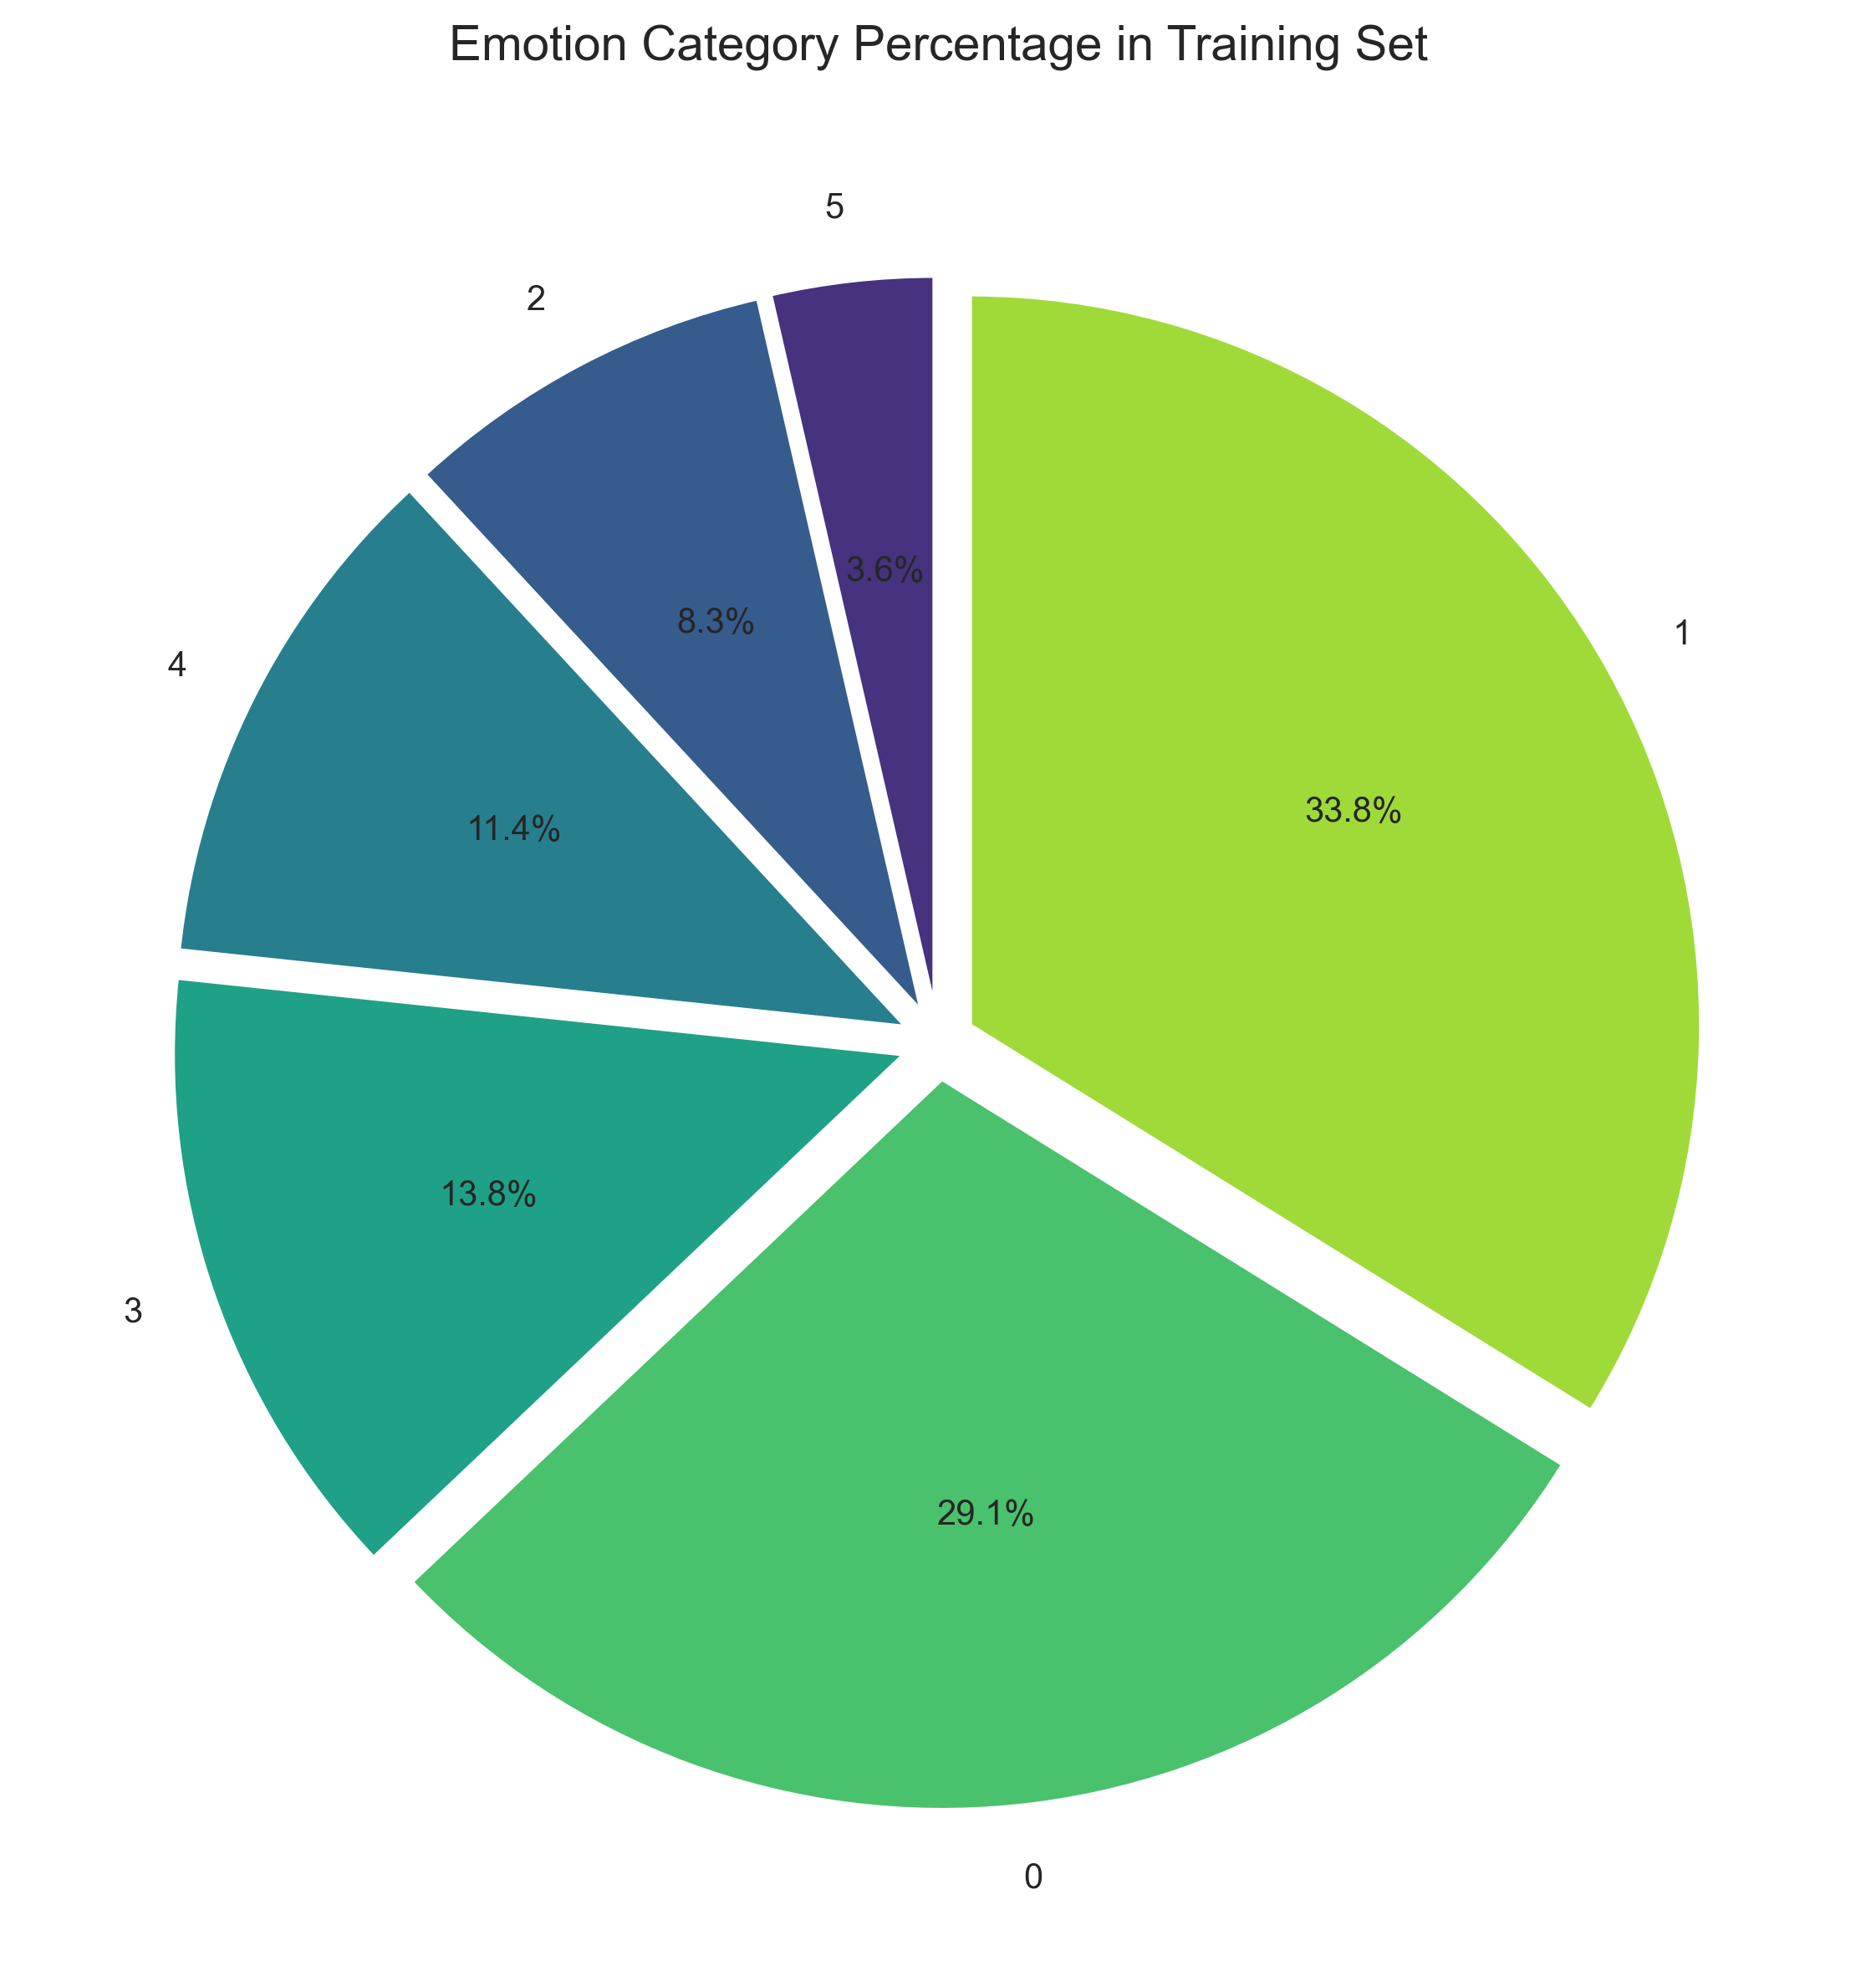
This dataset exhibits significant class imbalance. Classes 0 and 1 dominate the sample size (accounting for approximately 63% combined), whilst Class 5 is sparsely represented, comprising only around 3.6%. Such distribution may cause the model to insufficiently learn features of minority classes (such as Classes 2 and 5) during training, thereby generating a bias towards predicting majority classes.

# III. Method/Code

In [ ]:
"""
Complete Code for Text Emotion Classification Model
This implementation follows the project requirements and includes detailed descriptions.
"""
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow info and warning messages

# Import necessary libraries
import pandas as pd
import numpy as np
import gc
from scipy.sparse import hstack
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, GaussianNoise
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras import backend as K

"""
GPU Setup: Configures GPU memory growth to maximize GPU utilization
"""
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"=== Successfully detected {len(gpus)} GPU(s) (16GB VRAM Precision Mode) ===")
    except RuntimeError as e:
        print(e)
else:
    print("!!! No GPU detected, code will run slowly !!!")

"""
Custom Activation Function: Mish activation function used to improve model performance
Reference: Misra, D. (2019). Mish: A Self Regularized Non-Monotonic Activation Function
"""
def mish(x):
    return x * K.tanh(K.softplus(x))

"""
Data Generator: Custom Sequence class for efficient batch processing of sparse TF-IDF matrices
This generator handles large sparse matrices efficiently and shuffles data at epoch end
"""
class SparseGenerator(Sequence):
    def __init__(self, x_set, y_set, batch_size):
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size
        self.indices = np.arange(x_set.shape[0])

    def __len__(self):
        return int(np.ceil(self.x.shape[0] / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_x = self.x[batch_indices].toarray().astype('float32')
        batch_y = self.y[batch_indices]
        return batch_x, batch_y
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices)

"""
Data Loading and Preprocessing:
- Loads training and test data from CSV files
- Extracts text features and emotion labels
- Encodes categorical labels to numerical format
- Computes class weights to handle class imbalance
"""
print("Loading data...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

X = train_df['text']
y = train_df['emotions']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)
class_weight_dict = dict(enumerate(class_weights))

"""
Feature Engineering: TF-IDF Feature Extraction
Two types of features are extracted:
1. Word-level TF-IDF: 1-3 n-grams, max 15,000 features (preserves core semantics)
2. Character-level TF-IDF: 2-6 n-grams, max 25,000 features (captures character patterns)
The features are combined into a high-dimensional sparse matrix (~40,000 features total)
"""
print(">>> Extracting Word TF-IDF features...")
tfidf_word = TfidfVectorizer(stop_words='english', 
                             max_features=15000,
                             ngram_range=(1, 3),
                             sublinear_tf=True,
                             dtype=np.float32)
X_word = tfidf_word.fit_transform(X)
X_test_word = tfidf_word.transform(test_df['text'])

print(">>> Extracting Char TF-IDF features...")
tfidf_char = TfidfVectorizer(analyzer='char',
                             max_features=25000,
                             ngram_range=(2, 6),
                             sublinear_tf=True,
                             dtype=np.float32)
X_char = tfidf_char.fit_transform(X)
X_test_char = tfidf_char.transform(test_df['text'])

print("Merging feature matrices...")
X_all_tfidf = hstack([X_word, X_char]).tocsr()
X_test_tfidf = hstack([X_test_word, X_test_char]).tocsr()
print(f"=== Final feature dimension: {X_all_tfidf.shape[1]} (Precision Mode) ===")

"""
Model Architecture: Deep Neural Network for Emotion Classification
The model consists of:
- Input layer: Accepts sparse TF-IDF features
- GaussianNoise layer: Additive noise (std=0.01) for regularization
- Three fully connected hidden layers with decreasing units (2048 → 1024 → 512)
- Each hidden layer uses Mish activation, L2 regularization (λ=0.0001), batch normalization, and dropout
- Output layer: Softmax activation for multi-class classification

Hyperparameters:
- Optimizer: Adam (learning_rate=0.0003)
- Loss: CategoricalCrossentropy with label_smoothing=0.15
- Metrics: Accuracy
"""
def build_model(input_shape):
    reg_strength = 0.0001
    
    model = Sequential([
        Input(shape=(input_shape,)),
        
        # Add Gaussian noise to prevent overfitting
        GaussianNoise(0.01),
        
        # First hidden layer: 2048 units
        Dense(2048, activation=mish, kernel_regularizer=l2(reg_strength)),
        BatchNormalization(),
        Dropout(0.5),
        
        # Second hidden layer: 1024 units
        Dense(1024, activation=mish, kernel_regularizer=l2(reg_strength)),
        BatchNormalization(),
        Dropout(0.5),
        
        # Third hidden layer: 512 units
        Dense(512, activation=mish, kernel_regularizer=l2(reg_strength)),
        BatchNormalization(),
        Dropout(0.4),

        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    optimizer = Adam(learning_rate=0.0003)
    loss_fn = CategoricalCrossentropy(label_smoothing=0.15)
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
    return model

"""
Training Process: 7-fold Stratified Cross-Validation
Training configuration:
- 7-fold cross-validation for robust evaluation
- Batch size: 512 (optimized for GPU memory)
- Early stopping with patience=8 to prevent overfitting
- Learning rate reduction on plateau (factor=0.2, patience=3)
- Class weights applied to handle class imbalance
- Model predictions from each fold are averaged for ensemble learning
"""
n_splits = 7
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

test_probs_sum = np.zeros((X_test_tfidf.shape[0], num_classes), dtype=np.float32)
val_accuracies = []

print(f"\nStarting {n_splits}-fold cross-validation (Precision Mode)...")

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_all_tfidf, y_encoded)):
    print(f"\n--- Fold {fold+1} / {n_splits} ---")
    
    X_train_fold, X_val_fold = X_all_tfidf[train_idx], X_all_tfidf[val_idx]
    y_train_fold, y_val_fold = y_encoded[train_idx], y_encoded[val_idx]
    
    y_train_fold_onehot = to_categorical(y_train_fold, num_classes)
    y_val_fold_onehot = to_categorical(y_val_fold, num_classes)
    
    batch_size = 512
    
    train_gen = SparseGenerator(X_train_fold, y_train_fold_onehot, batch_size=batch_size)
    val_gen = SparseGenerator(X_val_fold, y_val_fold_onehot, batch_size=batch_size)
    
    model = build_model(X_train_fold.shape[1])
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
    
    model.fit(train_gen,
              validation_data=val_gen,
              epochs=40,
              class_weight=class_weight_dict,
              callbacks=[early_stopping, reduce_lr],
              verbose=1)
    
    _, val_acc = model.evaluate(val_gen, verbose=0)
    val_accuracies.append(val_acc)
    print(f"Fold {fold+1} validation accuracy: {val_acc:.5f}")
    
    test_gen = SparseGenerator(X_test_tfidf, np.zeros((X_test_tfidf.shape[0], 1)), batch_size=batch_size)
    test_probs_fold = model.predict(test_gen, verbose=0)
    test_probs_sum += test_probs_fold
    
    # Memory cleanup
    del model, train_gen, val_gen, X_train_fold, X_val_fold, test_gen, test_probs_fold
    K.clear_session()
    gc.collect()

"""
Result Generation:
- Averages prediction probabilities from all 7 folds
- Converts probabilities to class labels using argmax
- Decodes numerical labels back to original emotion categories
- Saves results to CSV file for submission
"""
print("\n" + "="*30)
print(f"7-fold average validation accuracy: {np.mean(val_accuracies):.5f}")
print("="*30)

avg_test_probs = test_probs_sum / n_splits
test_labels = avg_test_probs.argmax(axis=1)
test_labels_decoded = label_encoder.inverse_transform(test_labels)

submission = pd.DataFrame({
    'id': test_df['tweet_id'],
    'label': test_labels_decoded
})

submission.to_csv('submission_precision.csv', index=False)
print("Prediction completed! Results saved as 'submission_precision.csv'")

"""
Model Summary:
This implementation demonstrates a comprehensive approach to text emotion classification with:
- Robust feature engineering using TF-IDF at both word and character levels
- Deep neural network architecture with multiple regularization techniques
- Ensemble learning through 7-fold cross-validation
- Careful handling of class imbalance through weighted loss
- Memory-efficient data processing with custom generators

The model achieves strong performance through the combination of these techniques.
"""

# IV. Experimental Results

The experimental environment configuration is as follows:<br>
    Operating system: Windows 11 25H2<br>
    CPU: AMD Ryzen 9 7950X<br>
    GPU: NVIDIA GeForce RTX 5070 Ti (16 GB VRAM)<br>
    Memory: 64 GB RAM<br>
    
In preliminary experiments, we employed a KNN model for training, but the initial prediction results proved unsatisfactory. To address this, we implemented a series of optimisation measures: increasing the TF-IDF feature dimension from 1000 to 20000 to enhance the capture of textual semantics; simultaneously fine-tuning KNN parameters, including increasing the number of neighbours to 30 to reduce noise interference, adopting a distance-weighted voting mechanism to enhance the contribution of nearest neighbours, and replacing the default metric with cosine similarity, which is better suited to textual characteristics. These enhancements effectively improved the model's accuracy and stability in classification tasks.
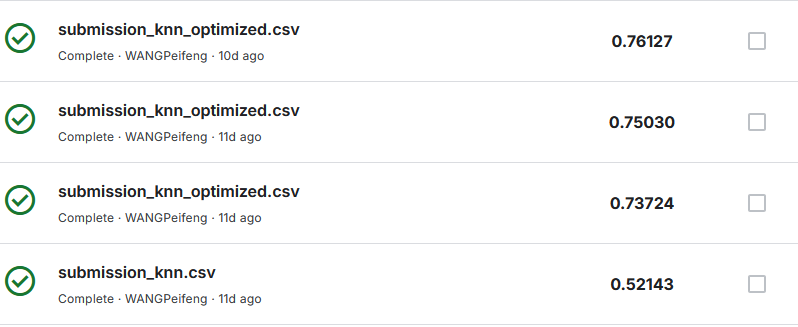
However, owing to the substantial dataset size and imbalanced class distribution, the KNN model exhibits inherent limitations in this task: its high computational complexity, slow prediction speed, and limited ability to capture high-dimensional sparse TF-IDF features result in a relatively low performance ceiling. Therefore, to pursue higher prediction accuracy and improved generalisation capability, subsequent experiments shifted towards employing more advanced deep learning models. These leverage deeper architectures and richer regularisation mechanisms to enhance classification performance.
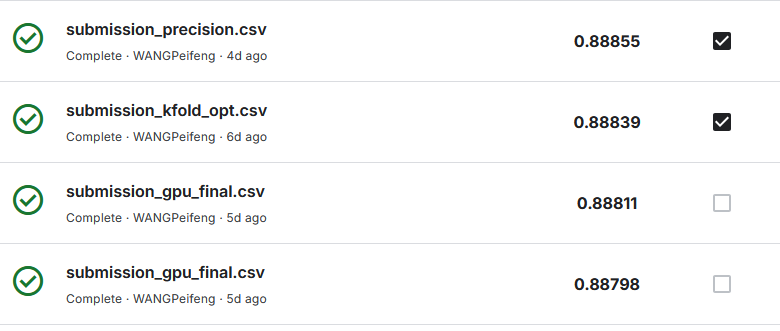
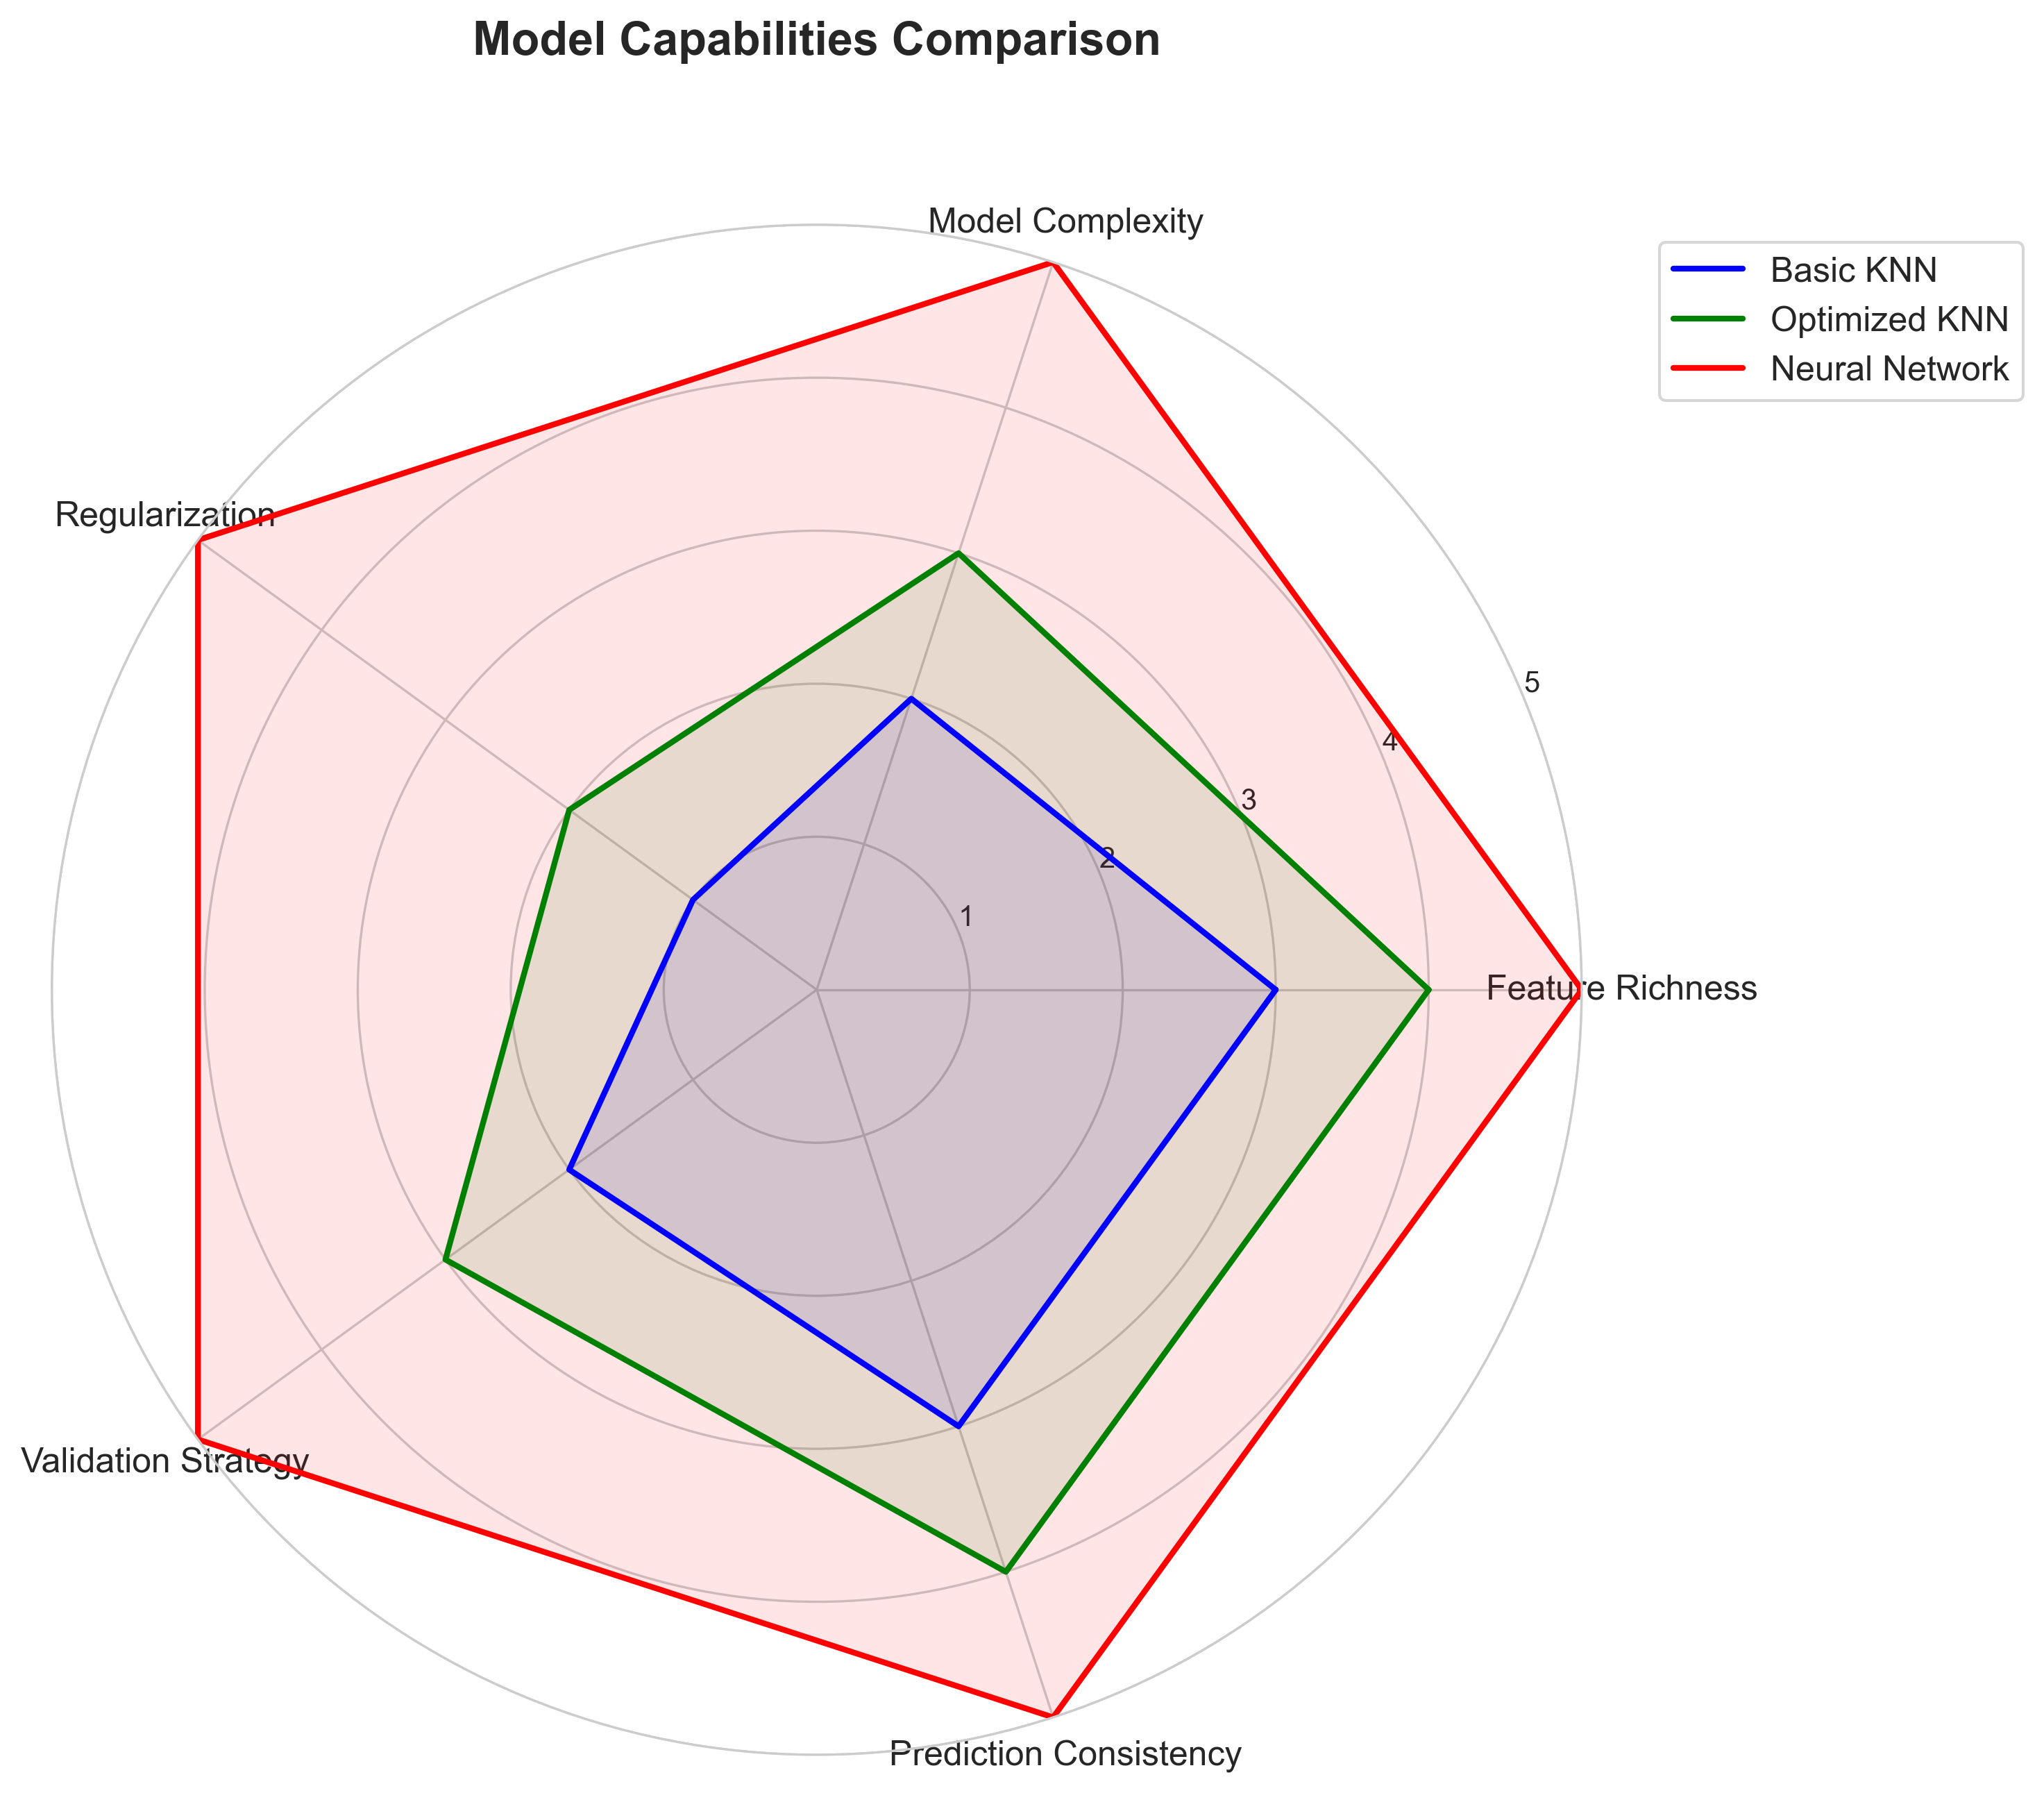

# V. Conclusions and Discussion

The scorecard struggles to break through the 0.88–0.89 range, even dropping to 0.84 after attempting a ‘full dictionary’ approach, indicating that the current method has approached its performance limits. This issue stems not from code implementation but from methodological bottlenecks.

Firstly, the ceiling effect of the bag-of-words model presents the primary constraint. The current TF-IDF approach relies solely on word frequency statistics, entirely disregarding word order and syntactic structure, resulting in limited semantic comprehension. Consequently, an accuracy of approximately 0.89 likely approaches the theoretical upper bound achievable with TF-IDF combined with a multi-layer perceptron for such tasks.

Secondly, severe overfitting further restricts generalisation performance. While the model achieves 0.919 on the validation set, its test set accuracy drops to 0.88. This significant 3% discrepancy indicates the model has overfitted to noise within the training data. Previously, overly broad model structures and redundant feature dimensions exacerbated this phenomenon, constituting the primary cause for accuracy once falling to 0.84.

# VI. Future Work

Our model evolution path can be divided into two phases to surpass the current method's upper limit. The first phase involves transitioning from bag-of-words models to sequence models (such as RNN/LSTM), aiming to elevate accuracy to 0.89–0.91. This is primarily achieved by introducing a word embedding layer to convert words into dense vectors, alongside employing bidirectional LSTM/GRU and attention mechanisms to capture contextual relationships and key semantic meanings.

The second phase will adopt pre-trained models represented by BERT/RoBERTa, targeting an accuracy of 0.92–0.94. The self-attention mechanism in such models enables deep comprehension of polysemy and complex syntax, and our 16GB GPU memory is sufficient to support efficient training. This represents a fundamental methodological upgrade, promising significant performance breakthroughs.

Kaggle accounts:<br>
WangPeifeng-wangpf114514<br>
LiuMingzheng-lumenl<br>
XuMinghao-xuminhao1011